# Introducción a la visualización de datos

En este notebook introducimos herramientas básicas de visualización en Python.

Trabajaremos con:

- matplotlib
- seaborn

Utilizaremos datos reales de COVID-19.

---

## Objetivos

- Representar series temporales  
- Comparar valores entre categorías  
- Visualizar matrices de datos  
- Crear múltiples gráficos (subplots)

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")

In [31]:
covid =  pd.read_csv("data/covid19/casos_hosp_uci_def_sexo_edad_provres.csv")

covid = covid.rename(columns={
    "provincia_iso": "province",
    "fecha": "date",
    "num_casos": "cases"
})

covid["date"] = pd.to_datetime(covid["date"])

covid.head()

,province,sexo,grupo_edad,date,cases,num_hosp,num_uci,num_def
0,A,H,0-9,2020-01-01,0,0,0,0
1,A,H,10-19,2020-01-01,0,0,0,0
2,A,H,20-29,2020-01-01,0,0,0,0
3,A,H,30-39,2020-01-01,0,0,0,0
4,A,H,40-49,2020-01-01,0,0,0,0


## Series temporales

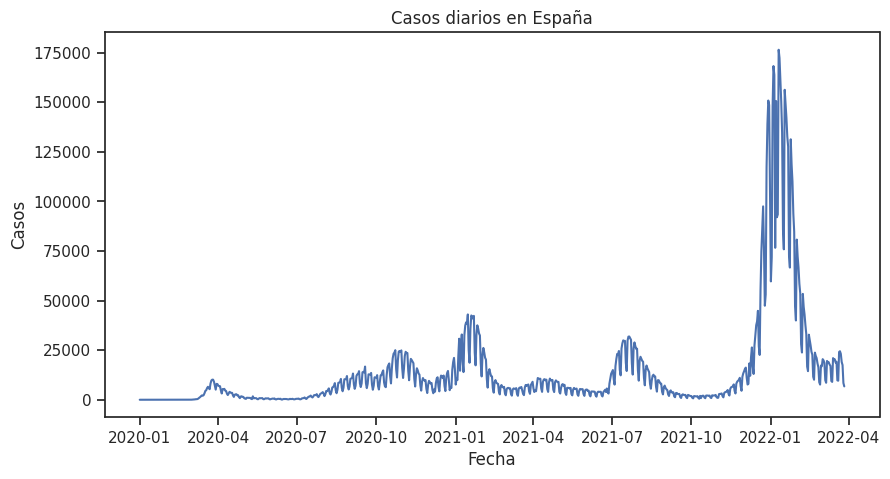

In [32]:
covid_agg = covid.groupby(["date"])["cases"].sum().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(covid_agg["date"], covid_agg["cases"])
plt.title("Casos diarios en España")
plt.xlabel("Fecha")
plt.ylabel("Casos")
plt.show()

# Ejercicio
Representa la serie temporal de casos para una provincia concreta.

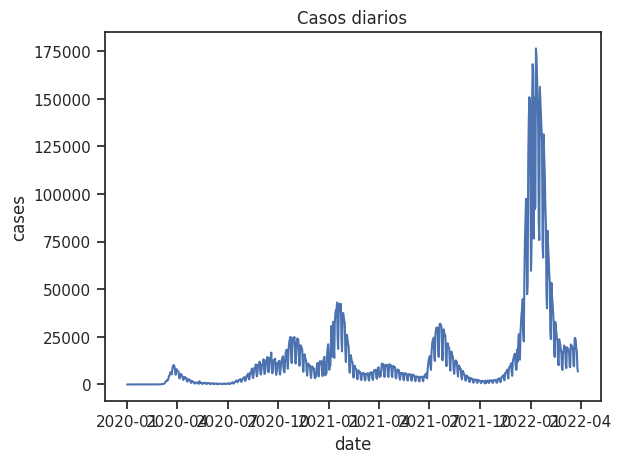

In [33]:
sns.lineplot(data=covid_agg, x="date", y="cases")
plt.title("Casos diarios")
plt.show()

## Comparación entre regiones

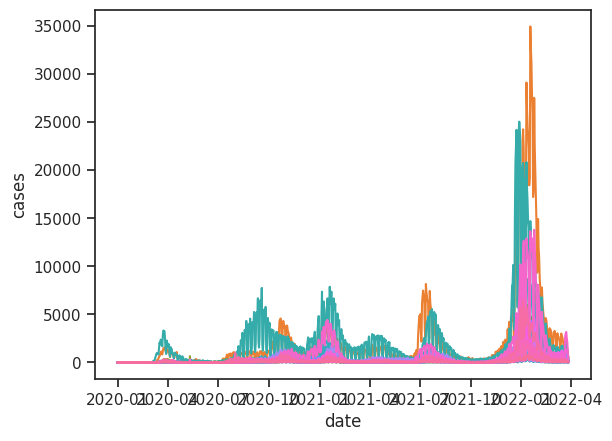

In [34]:
covid_prov = covid.groupby(["date", "province"])["cases"].sum().reset_index()

sns.lineplot(data=covid_prov, x="date", y="cases", hue="province", legend=False)
plt.show()

## Ejercicio
Selecciona 3 provincias y compara sus curvas.

## Comparación con barras

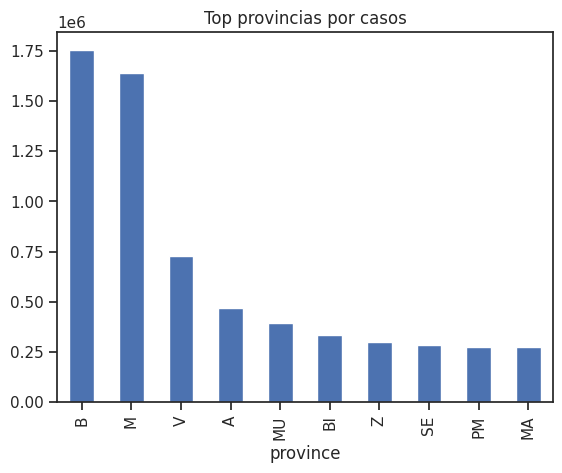

In [35]:
covid_total = covid.groupby("province")["cases"].sum().sort_values(ascending=False)

covid_total.head(10).plot(kind="bar")
plt.title("Top provincias por casos")
plt.show()

## Múltiples gráficos

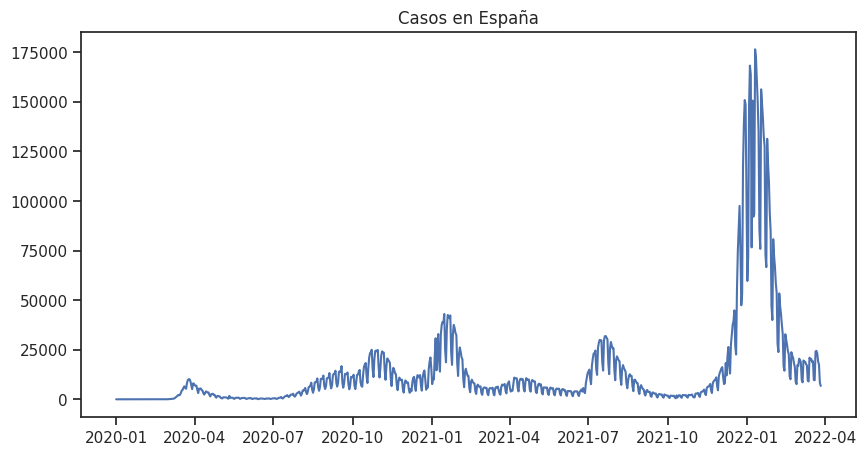

In [36]:
covid_spain = covid.groupby("date")[["cases"]].sum()

fig, ax = plt.subplots(1,1,figsize=(10, 5))

ax.plot(covid_spain.index, covid_spain["cases"])
ax.set_title("Casos en España")

plt.show()

## Ejercicio

Crea 2 subplots:
- casos  
- hospitalizaciones  

## Matriz como heatmap

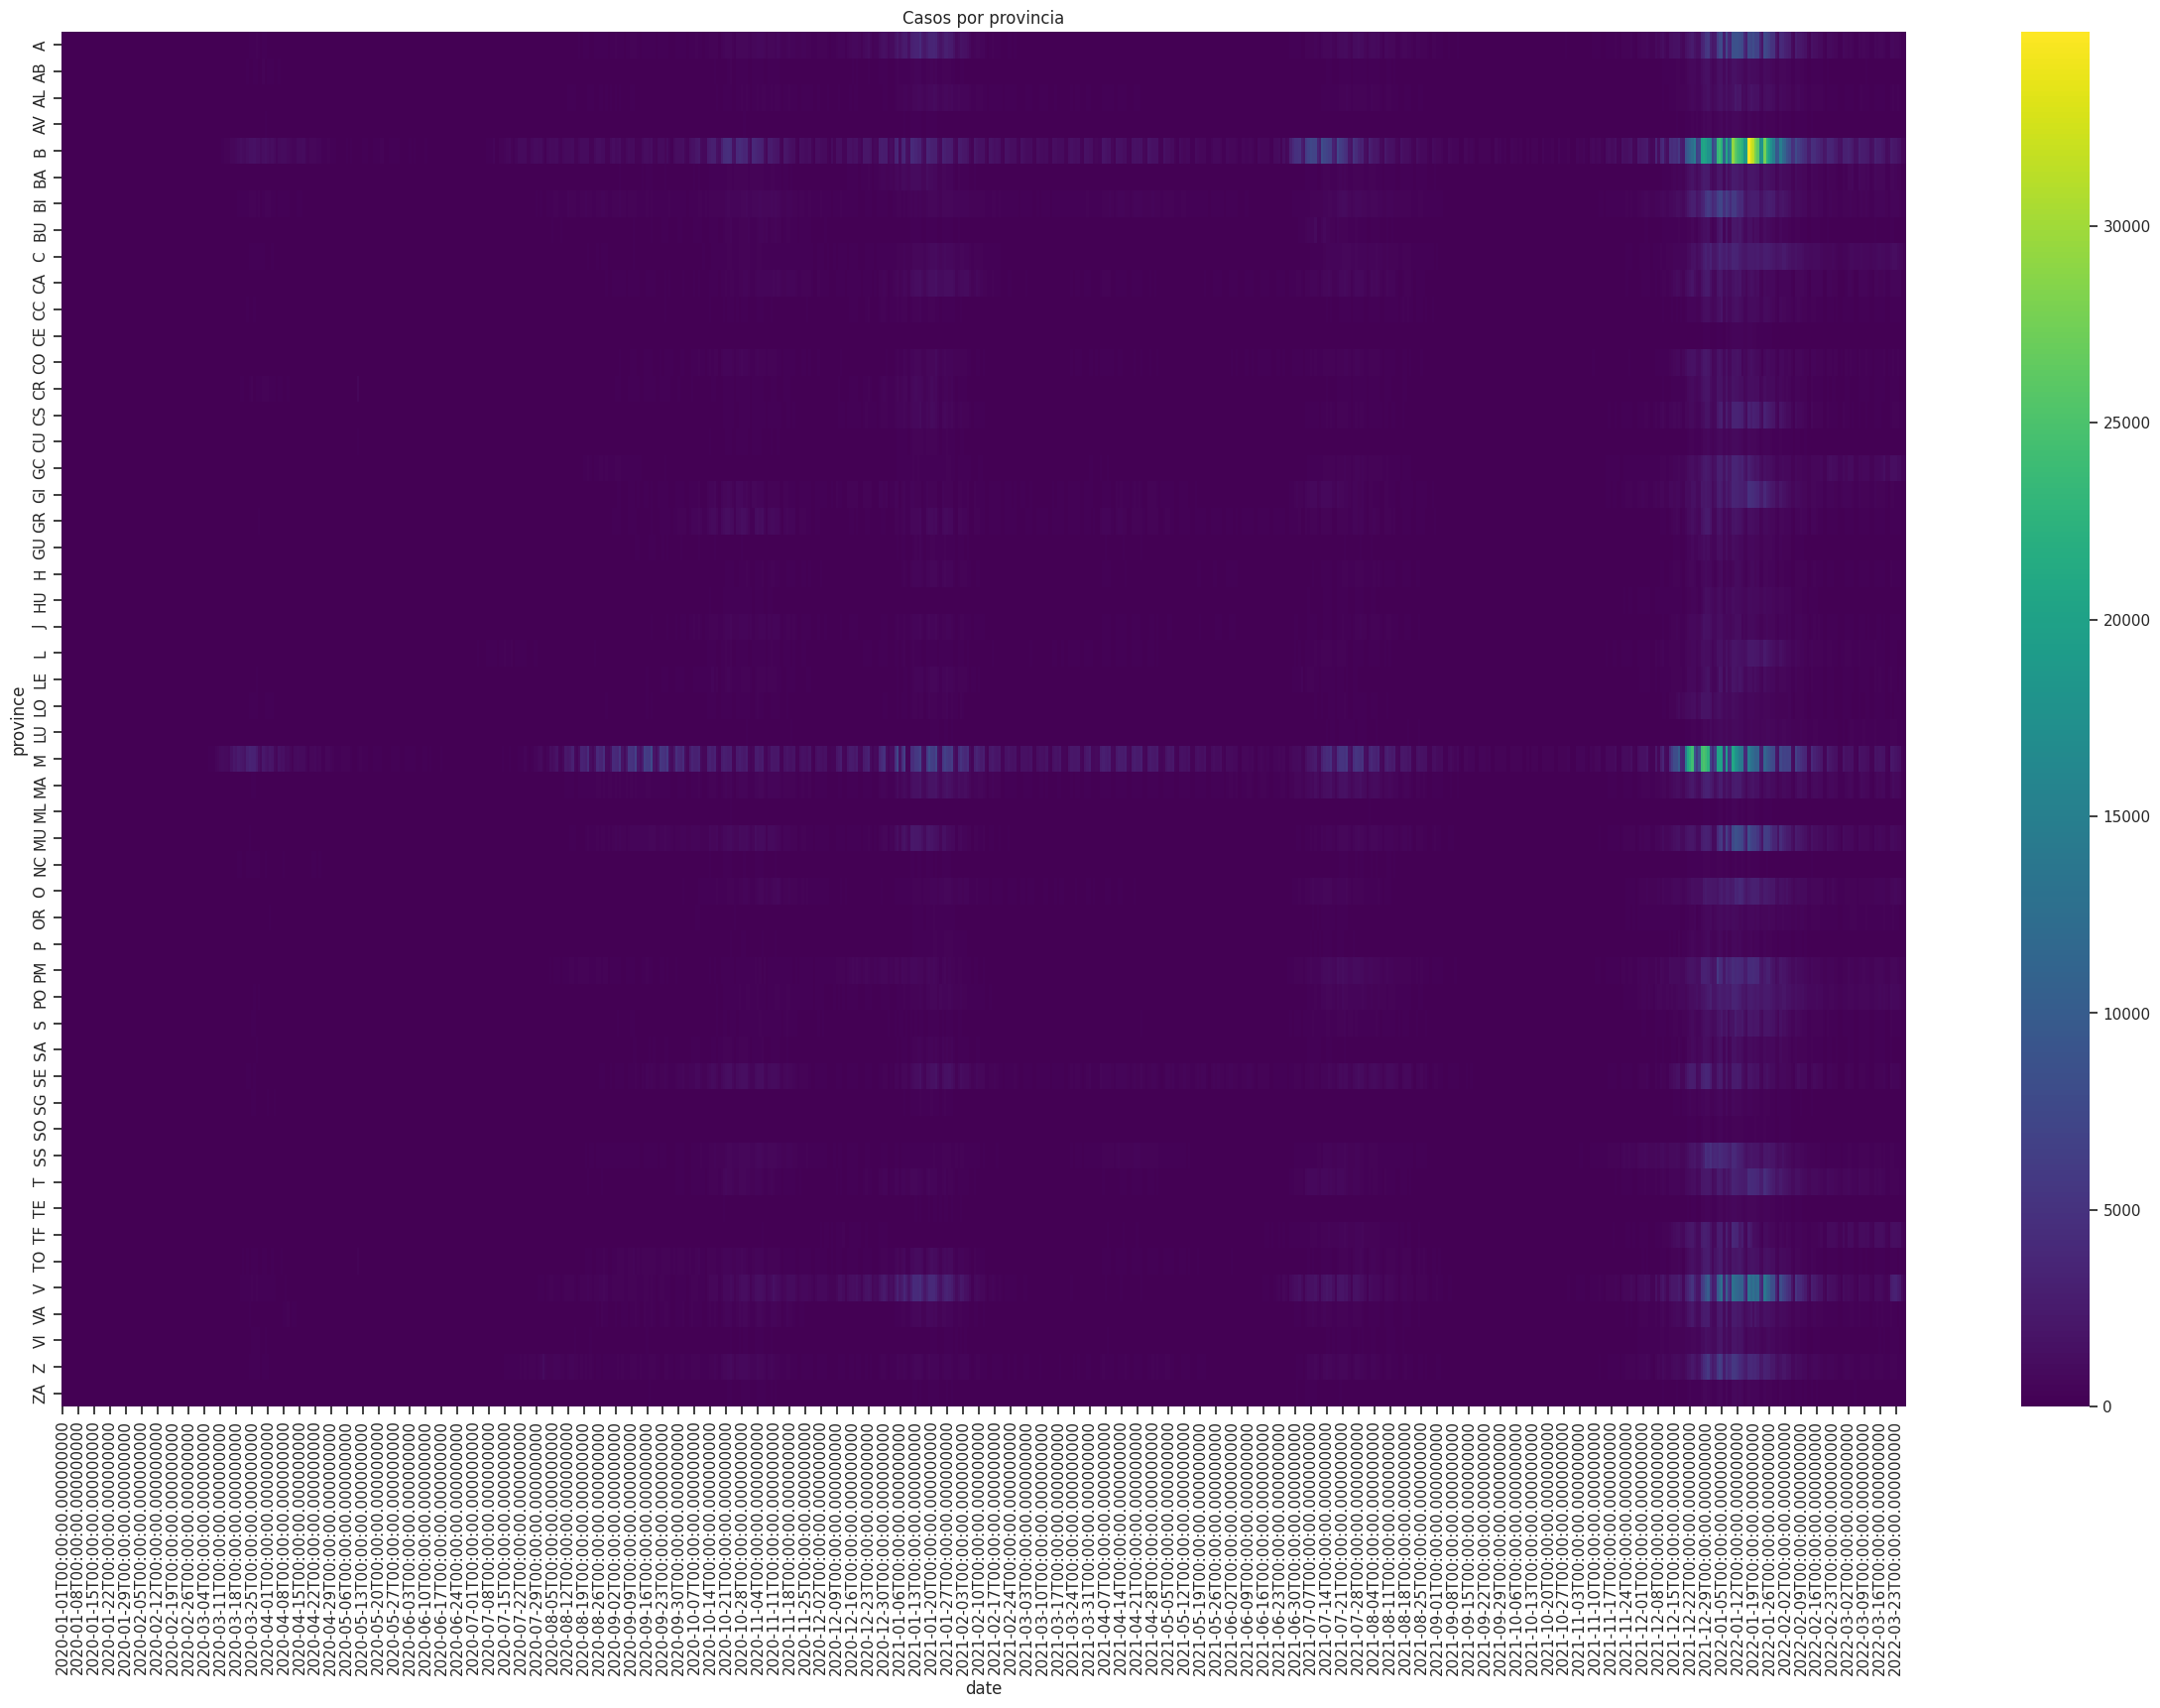

In [37]:
pivot = covid_prov.pivot(
    index="province",
    columns="date",
    values="cases"
)

plt.figure(figsize=(30, 18))
sns.heatmap(pivot.fillna(0), cmap="viridis")
plt.title("Casos por provincia")
plt.show()

## Visualización por múltiples regiones

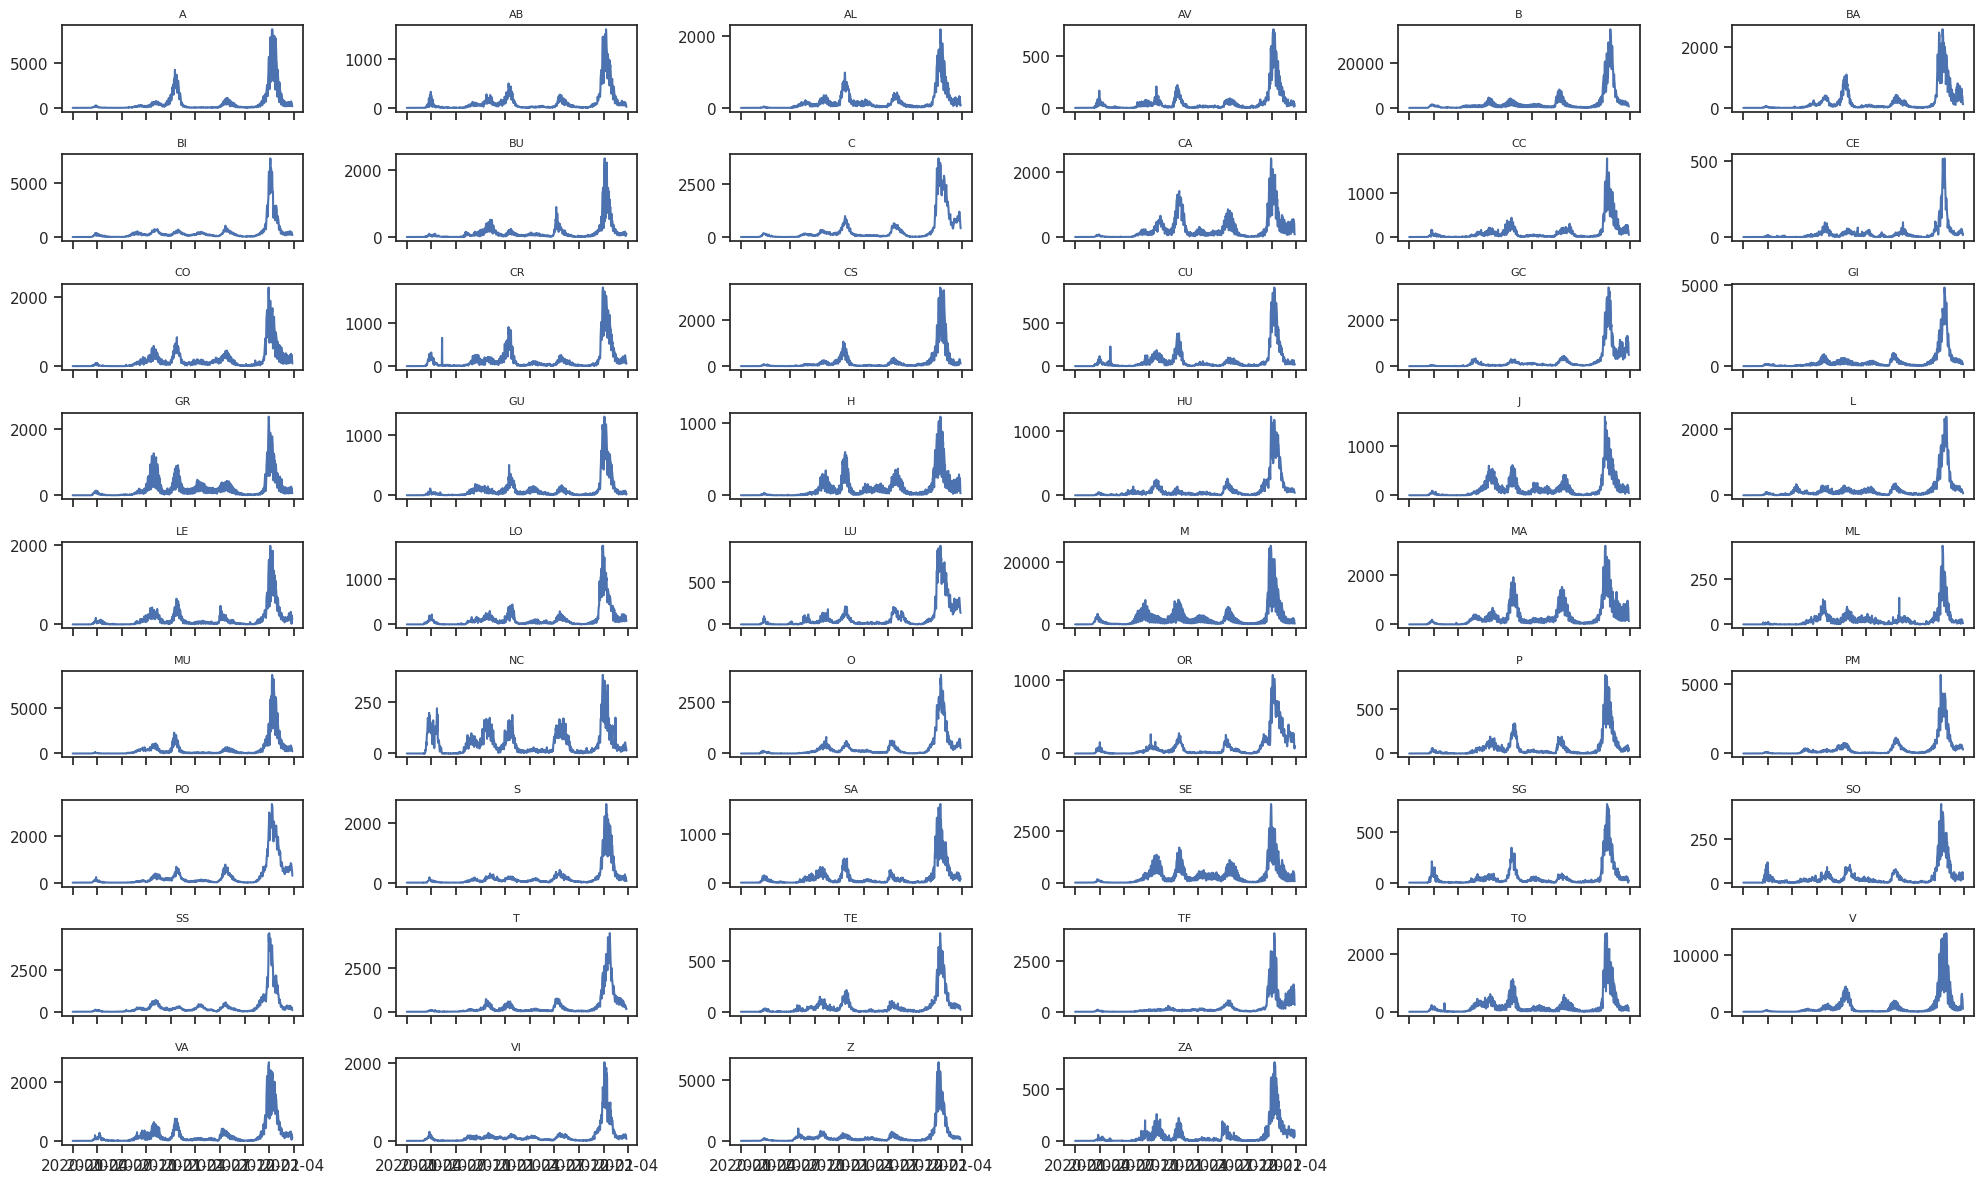

In [39]:
provinces = covid_prov["province"].unique()

fig, axes = plt.subplots(9, 6, figsize=(20, 12), sharex=True)
axes = axes.flatten()

for i, prov in enumerate(provinces[:54]):
    data = covid_prov[covid_prov["province"] == prov]
    axes[i].plot(data["date"], data["cases"])
    axes[i].set_title(prov, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()